# Mean estimation for Gaussian Distributions
From https://arxiv.org/pdf/2102.07698

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable
from collections import deque
import torch

In [45]:
def PerfGD(
    f_hat: Callable,
    grad2_est: Callable,
    D_theta: Callable,
    loss: Callable,
    theta_0: torch.Tensor,
    proj_theta: Callable = lambda x: x,
    n: int = 16,
    eta: float = 0.01,
    H: int = 100,
    tol: float = 1e-5,
    max_iter: int = 5000
):
    
    all_thetas = [theta_0.clone().detach().squeeze()]

    theta_history = deque(maxlen=H)
    f_history = deque(maxlen=H)

    # First take H steps of RGD
    theta_t = theta_0
    for t in range(H):

        z = D_theta(theta_t, n) # Draw n samples from D(theta)
        f_t = f_hat(z)  # Estimate for f(theta)

        theta_history.append(theta_t.detach())
        f_history.append(f_t.detach())

        # Gradient descent step on Loss_1 loss
        theta_t.requires_grad_(True)
        theta_t.grad = None 
        l_t = loss(z, theta_t).mean(dim=-1)
        l_t.backward()
        dL1 = theta_t.grad

        with torch.no_grad():
            theta_t = proj_theta(theta_t - eta * dL1)

        all_thetas.append(theta_t.detach().squeeze())

    # Not run with full gradient update
    converged = False
    t = H
    while not converged:

        z = D_theta(theta_t, n) # Draw n samples from D(theta) (d x n)
        f_t = f_hat(z) # (d,)
        
        theta_history.append(theta_t.detach())
        f_history.append(f_t.detach())

        theta_t.requires_grad_(True)
        theta_t.grad = None 
        l_t = loss(z, theta_t).mean(dim=-1)
        l_t.backward()
        dL1 = theta_t.grad
        
        Theta_full = torch.stack([th for th in theta_history], dim=1)   # (p, ≤H+1)
        F_full = torch.stack([fh for fh in f_history], dim=1)   # (q, ≤H+1)
        
        Theta = Theta_full[:, :-1]                                      # (p, H) -> t-H : t-1
        F = F_full[:, :-1]
        oneH = torch.ones(1, Theta.shape[1], device=Theta.device)

        delta_theta = Theta - theta_t.unsqueeze(1) @ oneH          # (p, H)
        delta_f = F - f_t.unsqueeze(1) @ oneH          # (q, H)

        df_d_theta = delta_f @ torch.linalg.pinv(delta_theta) # (p x q)

        dL2 = grad2_est(z, f_t, theta_t, df_d_theta)

        with torch.no_grad():
            theta_t = proj_theta(theta_t - eta * (dL1 + dL2))

        all_thetas.append(theta_t.detach().squeeze())
        
        if (dL1 + dL2).norm() < tol: 
            break # Converged
        
        t += 1
        if t > max_iter: 
            break # Max iterations
    
    return theta_t, all_thetas

### Example 5.1: Mixture of Gaussians and nonlinear mean

#### Linear example

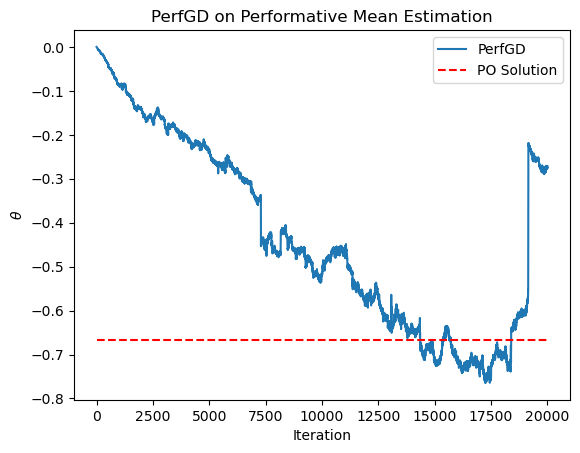

In [52]:
a0 = 1.0
a1 = 1.0
sigma = torch.tensor([[1.0]])
mu = lambda theta: torch.sqrt(a0*theta + a1) # Define mean function (determines performativity)
f_hat = lambda z: z.mean(dim=1)
D_theta = lambda theta, n: torch.normal(mu(theta).squeeze(), 1.0, size=(1,n))
loss = lambda z, theta: z*theta
def grad2_est(z, f, theta, df_d_theta):
    if z.ndim == 1: z = z.unsqueeze(0)
    if f.ndim == 1: f = f.unsqueeze(0)
    return torch.mean( loss(z, theta) * (df_d_theta.T @ torch.linalg.inv(sigma) @ (z - f)), dim=-1)

proj_theta = lambda x: x.clamp(min=-1.0, max=1.0)

theta, all_theta = PerfGD(
    f_hat,
    grad2_est,
    D_theta,
    loss,
    theta_0 = torch.tensor([0.0]),
    proj_theta = proj_theta,
    n = 500,
    eta = 0.0001,
    H = 4,
    tol = 1e-8,
    max_iter = 20000
)

plt.plot(torch.stack(all_theta), label='PerfGD')
plt.hlines(-2*a0/(3*a1), 0, len(all_theta), colors='r', linestyles='dashed', label='PO Solution')
plt.legend()
plt.title('PerfGD on Performative Mean Estimation')
plt.xlabel('Iteration')
plt.ylabel(r'$\theta$')
plt.show()